In [14]:
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
import numpy as np
import cv2


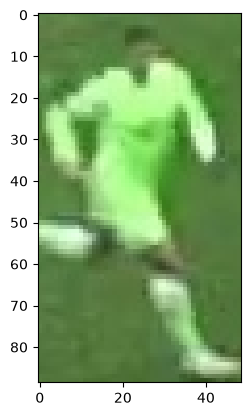

In [11]:
img_path = "../data/output/player_1.jpg"
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {img_path}")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()


Text(0.5, 1.0, 'Top Half')

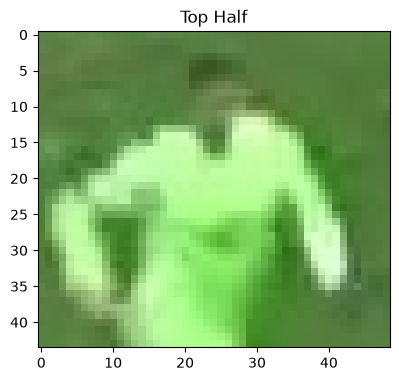

In [12]:
top_half = img[0:img.shape[0]//2, :]
bottom_half = img[img.shape[0]//2:, :]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(top_half, cv2.COLOR_BGR2RGB))
plt.title("Top Half")

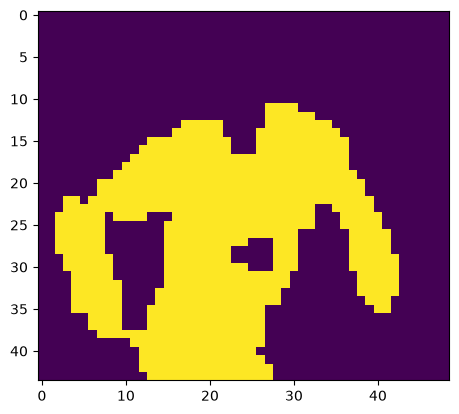

In [22]:
image_2d = top_half.reshape(-1, 3)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(image_2d)

labels = kmeans.labels_

labels_reshaped = labels.reshape(top_half.shape[0], top_half.shape[1])

plt.imshow(labels_reshaped)
plt.show()

In [26]:
corner_clusters = [labels_reshaped[0, 0], labels_reshaped[0, -1], labels_reshaped[-1, 0], labels_reshaped[-1, -1]]
non_player_cluster = max(set(corner_clusters), key=corner_clusters.count)
print(non_player_cluster)

0


In [24]:
player_cluster = 1 - non_player_cluster
print(player_cluster)

1


In [27]:
kmeans.cluster_centers_[player_cluster]

array([142.74965986, 236.14965986, 170.65578231])